  เอกสารเชิงปฏิบัติการ: การเรียนรู้ Convolutional Neural Networks ด้วย PyTorch และชุดข้อมูล MNIST

เอกสารเชิงปฏิบัติการฉบับนี้ มีวัตถุประสงค์เพื่อแนะนำหลักการทำงานของ **Convolutional Neural Networks (CNNs)** ซึ่งเป็นสถาปัตยกรรมโครงข่ายประสาทเทียมที่มีประสิทธิภาพสูง และเป็นรากฐานสำคัญของเทคโนโลยี Computer Vision ในปัจจุบัน

**วัตถุประสงค์:**
1.  **เพื่อทำความเข้าใจแนวคิดพื้นฐาน:** อธิบายหลักการที่ทำให้ CNN เหมาะสมกับการประมวลผลข้อมูลรูปภาพ
2.  **เพื่อเปรียบเทียบประสิทธิภาพ:** แสดงให้เห็นถึงความแตกต่างระหว่างแบบจำลอง **Multi-Layer Perceptron (MLP)** และ **CNN**
3.  **เพื่อฝึกฝนการนำไปใช้:** สาธิตการสร้างและฝึกสอนแบบจำลองทั้งสองประเภทด้วยไลบรารี PyTorch บนชุดข้อมูล **MNIST**


```
ไพรสันต์ ผดุงเวียง, CP, KKU, 2025
```



   ส่วนที่ 1: การตั้งค่าและการเตรียมข้อมูล (Setup and Data Preparation)

ในลำดับแรก จะเป็นการนำเข้าไลบรารีที่จำเป็น และดำเนินการดาวน์โหลดชุดข้อมูล MNIST ผ่าน `torchvision`

ขั้นตอนในส่วนนี้ประกอบด้วย 3 ส่วนหลัก:
- **การเลือกอุปกรณ์ประมวลผล (Device Selection):** ระบบจะตรวจสอบการมีอยู่ของหน่วยประมวลผลกราฟิก (GPU) ที่รองรับ CUDA เพื่อใช้ในการเร่งความเร็ว หากไม่พบจะใช้หน่วยประมวลผลกลาง (CPU) เป็นค่าเริ่มต้น
- **การแปลงข้อมูล (Data Transformation):** รูปภาพในชุดข้อมูลจะถูกแปลงให้อยู่ในรูปแบบ Tensor และจะมีการทำ Normalization เพื่อปรับค่าพิกเซลโดยใช้ค่าเฉลี่ย (mean) และส่วนเบี่ยงเบนมาตรฐาน (std) เท่ากับ 0.5 ซึ่งจะช่วยเพิ่มเสถียรภาพในการเรียนรู้ของแบบจำลอง
- **การสร้าง DataLoader:** เป็นการจัดเตรียมข้อมูลให้อยู่ในรูปแบบชุดข้อมูลย่อย (mini-batch) สำหรับป้อนเข้าสู่กระบวนการฝึกสอนแบบจำลอง

In [40]:
  Import libraries ที่จำเป็น
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

  1. ตรวจสอบและเลือก Device (GPU ถ้ามี, มิฉะนั้นใช้ CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   ตรวจสอบว่ามี GPU ที่รองรับ CUDA หรือไม่ หากมีให้ใช้ 'cuda' มิฉะนั้นให้ใช้ 'cpu'
print(f'Using device: {device}')

  กำหนดค่า Hyperparameters
BATCH_SIZE = 13000
LEARNING_RATE = 0.001
EPOCHS = 5   เราจะใช้จำนวน epoch น้อยๆ เพื่อให้ workshop จบในเวลาที่กำหนด

  2. กำหนดขั้นตอนการแปลงข้อมูล
transform = transforms.Compose([   สร้างลำดับขั้นตอนการแปลงข้อมูลรูปภาพ
    transforms.ToTensor(),   แปลงรูปภาพ PIL Image หรือ NumPy ndarray ให้เป็น FloatTensor ซึ่งมีค่าอยู่ในช่วง [0.0, 1.0]
    transforms.Normalize((0.5,), (0.5,))   ปรับค่าพิกเซลโดยใช้ค่าเฉลี่ย (mean) และส่วนเบี่ยงเบนมาตรฐาน (std) เท่ากับ 0.5
])

  3. ดาวน์โหลดและเตรียมชุดข้อมูล MNIST ที่มีอยู่แล้วใน torchvision
  Training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',   ระบุตำแหน่งที่จัดเก็บข้อมูลเพื่อ download ข้อมูลมาเก็บไว้
    train=True,   ระบุว่าเป็นชุดข้อมูลสำหรับฝึกสอน
    transform=transform,   กำหนดให้ใช้ขั้นตอนการแปลงข้อมูลที่สร้างไว้
    download=True   อนุญาตให้ดาวน์โหลดข้อมูลหากยังไม่มีในตำแหน่งที่ระบุ
)

  Test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,   ระบุว่าเป็นชุดข้อมูลสำหรับทดสอบ
    transform=transform
)

  4. สร้าง DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)   shuffle=True เพื่อสลับลำดับข้อมูลในแต่ละ epoch ซึ่งช่วยให้โมเดลเรียนรู้ได้ดีขึ้น
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)   shuffle=False เพื่อให้การประเมินผลมีความสอดคล้องกันทุกครั้ง

print(f"มีข้อมูลสำหรับฝึกสอน {len(train_dataset)} รูป")
print(f"มีข้อมูลสำหรับทดสอบ {len(test_dataset)} รูป")

Using device: cuda
มีข้อมูลสำหรับฝึกสอน 60000 รูป
มีข้อมูลสำหรับทดสอบ 10000 รูป


    การแสดงภาพตัวอย่างข้อมูล
เพื่อสร้างความเข้าใจลักษณะของข้อมูล จะมีการแสดงภาพตัวอย่างบางส่วนจากชุดข้อมูล พร้อมทั้งป้ายกำกับ (Label) ที่สอดคล้องกัน

ตัวอย่างรูปภาพ:


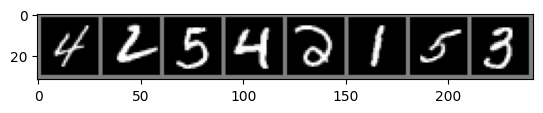

Labels:  4 2 5 4 2 1 5 3


In [28]:
  ฟังก์ชันสำหรับแสดงรูปภาพ
def imshow(img):
    img = img *0.5 + 0.5       ดำเนินการย้อนกลับกระบวนการ Normalization เพื่อให้ค่าพิกเซลกลับมาอยู่ในช่วง [0, 1] สำหรับการแสดงผล
    npimg = img.numpy()       แปลง Tensor ของรูปภาพให้เป็น NumPy array
    plt.imshow(np.transpose(npimg, (1, 2, 0)))   สลับมิติของ array จาก (C, H, W) เป็น (H, W, C) ตามรูปแบบที่ matplotlib ต้องการ
    plt.show()

  ดึงข้อมูลตัวอย่างมาหนึ่ง batch
dataiter = iter(train_loader)   สร้าง iterator จาก train_loader
images, labels = next(dataiter)   ดึงข้อมูลชุดย่อย (batch) แรกออกมา

  แสดงรูปภาพ
print('ตัวอย่างรูปภาพ:')
imshow(torchvision.utils.make_grid(images[:8]))   นำรูปภาพ 8 รูปแรกใน batch มาเรียงต่อกันเป็นตารางเพื่อแสดงผล
  พิมพ์ป้ายกำกับ
print('Labels: ', ' '.join(f'{labels[j].item()}' for j in range(8)))   แสดงป้ายกำกับที่สอดคล้องกับรูปภาพ 8 รูปแรก

   ส่วนที่ 2: แบบจำลองโครงข่ายประสาทหลายชั้น (Multi-Layer Perceptron - MLP)

    หลักการและทฤษฎีเบื้องต้น
MLP เป็นสถาปัตยกรรมโครงข่ายประสาทเทียมพื้นฐาน ซึ่งประกอบด้วยชั้นเซลล์ประสาทที่เชื่อมต่อกันอย่างสมบูรณ์ (Fully Connected Layer) หลายชั้นเรียงต่อกัน

**ข้อจำกัดของ MLP ต่อการประมวลผลข้อมูลรูปภาพ:**
1.  **การสูญเสียความสัมพันธ์เชิงพื้นที่:** การนำเข้าข้อมูลรูปภาพ (ขนาด 28x28 พิกเซล) จำเป็นต้องแปลงเป็นเวกเตอร์หนึ่งมิติ (ขนาด 784) ก่อน ซึ่งกระบวนการนี้ทำให้ข้อมูล **ความสัมพันธ์เชิงพื้นที่ (Spatial Relationship)** ระหว่างพิกเซลที่อยู่ใกล้เคียงกันสูญหายไป
2.  **จำนวนพารามิเตอร์ที่สูง:** สำหรับรูปภาพที่มีขนาดใหญ่ขึ้น จำนวนพารามิเตอร์ของแบบจำลองจะเพิ่มขึ้นอย่างมีนัยสำคัญ ส่งผลให้เกิดความซับซ้อนในการคำนวณและเพิ่มความเสี่ยงต่อภาวะ Overfitting

    การสร้างแบบจำลอง MLP

In [29]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()   เรียก Constructor ของคลาสแม่ (nn.Module) เพื่อเริ่มต้นการทำงาน
          ทำการคลี่รูปภาพ 28x28 ให้เป็นเวกเตอร์ขนาด 784
        self.flatten = nn.Flatten()   กำหนด Layer สำหรับแปลงข้อมูลภาพ 2 มิติให้เป็นเวกเตอร์ 1 มิติ
          สร้างชั้น Linear (Fully Connected) ต่อกัน
        self.layers = nn.Sequential(   สร้างกลุ่มของ Layers ที่จะทำงานเรียงตามลำดับ
            nn.Linear(28 * 28, 128),   ชั้น Input: รับเวกเตอร์ขนาด 784 (28x28) และส่งต่อไปยัง Hidden Layer ขนาด 128 โหนด
            nn.ReLU(),               ฟังก์ชันกระตุ้น (Activation Function) แบบ ReLU เพื่อเพิ่มความสามารถในการเรียนรู้ความสัมพันธ์ที่ไม่ใช่เชิงเส้น
            nn.Linear(128, 64),      ชั้น Hidden Layer ที่ 1: รับข้อมูล 128 โหนด และส่งต่อไปยัง Hidden Layer ที่ 2 ขนาด 64 โหนด
            nn.ReLU(),               ฟังก์ชันกระตุ้น (Activation Function)
            nn.Linear(64, 10)        ชั้น Output: รับข้อมูล 64 โหนด และส่งต่อไปยัง 10 โหนดสุดท้าย ซึ่งแทนความน่าจะเป็นของแต่ละคลาส (ตัวเลข 0-9)
        )

    def forward(self, x):
          เป็นเมธอดที่กำหนดการไหลของข้อมูลไปข้างหน้า (Forward Pass) ภายในโมเดล
        x = self.flatten(x)   แปลงข้อมูลภาพนำเข้า (x) ให้เป็นเวกเตอร์
        logits = self.layers(x)   ส่งเวกเตอร์ผ่านชั้น Sequential ที่ได้กำหนดไว้
        return logits   คืนค่าผลลัพธ์ (logits) ก่อนผ่านฟังก์ชัน Softmax

  สร้าง instance ของโมเดล และย้ายไปทำงานบน device ที่เลือกไว้
mlp_model = MLP().to(device)   สร้างอ็อบเจกต์ของโมเดล MLP และย้ายการคำนวณทั้งหมดไปอยู่บนอุปกรณ์ (CPU หรือ GPU) ที่กำหนด
print(mlp_model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [14]:
 @title MLP model
%%html
<svg width="1200" height="600" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="1200" height="600" fill=" f8f9fa"/>

  <!-- Title -->
  <text x="600" y="30" text-anchor="middle" font-family="Arial, sans-serif" font-size="20" font-weight="bold" fill=" 2c3e50">Multi-Layer Perceptron (MLP) Architecture</text>

  <!-- Input Layer -->
  <g id="input">
    <rect x="50" y="120" width="80" height="80" fill=" 3498db" stroke=" 2980b9" stroke-width="2"/>
    <text x="90" y="145" text-anchor="middle" font-family="Arial, sans-serif" font-size="11" fill="white" font-weight="bold">Input Image</text>
    <text x="90" y="165" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">28 × 28</text>
    <text x="90" y="180" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">pixels</text>
    <text x="90" y="220" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Input Layer</text>
  </g>

  <!-- Flatten Operation -->
  <g id="flatten">
    <rect x="200" y="130" width="60" height="60" fill=" f39c12" stroke=" e67e22" stroke-width="2"/>
    <text x="230" y="150" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">Flatten</text>
    <text x="230" y="165" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill="white">28×28→784</text>
    <text x="230" y="210" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Flatten</text>
  </g>

  <!-- Hidden Layer 1 -->
  <g id="hidden1">
    <rect x="330" y="100" width="100" height="120" fill=" e74c3c" stroke=" c0392b" stroke-width="2"/>
    <text x="380" y="125" text-anchor="middle" font-family="Arial, sans-serif" font-size="11" fill="white" font-weight="bold">Linear Layer</text>
    <text x="380" y="145" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">784 → 128</text>
    <text x="380" y="165" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">+</text>
    <text x="380" y="185" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">ReLU</text>
    <text x="380" y="205" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">Activation</text>
    <text x="380" y="240" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Hidden Layer 1</text>
    <text x="380" y="255" text-anchor="middle" font-family="Arial, sans-serif" font-size="11" fill=" 2c3e50">(128 neurons)</text>
  </g>

  <!-- Hidden Layer 2 -->
  <g id="hidden2">
    <rect x="500" y="110" width="100" height="100" fill=" e74c3c" stroke=" c0392b" stroke-width="2"/>
    <text x="550" y="135" text-anchor="middle" font-family="Arial, sans-serif" font-size="11" fill="white" font-weight="bold">Linear Layer</text>
    <text x="550" y="155" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">128 → 64</text>
    <text x="550" y="175" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">+</text>
    <text x="550" y="195" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">ReLU</text>
    <text x="550" y="230" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Hidden Layer 2</text>
    <text x="550" y="245" text-anchor="middle" font-family="Arial, sans-serif" font-size="11" fill=" 2c3e50">(64 neurons)</text>
  </g>

  <!-- Output Layer -->
  <g id="output">
    <rect x="670" y="120" width="80" height="80" fill=" 27ae60" stroke=" 229954" stroke-width="2"/>
    <text x="710" y="140" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">Linear Layer</text>
    <text x="710" y="155" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white">64 → 10</text>
    <text x="710" y="175" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill="white">Logits</text>
    <text x="710" y="185" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill="white">(Classes 0-9)</text>
    <text x="710" y="220" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Output Layer</text>
    <text x="710" y="235" text-anchor="middle" font-family="Arial, sans-serif" font-size="11" fill=" 2c3e50">(10 classes)</text>
  </g>

  <!-- Arrows -->
  <defs>
    <marker id="arrowhead" markerWidth="10" markerHeight="7"
     refX="0" refY="3.5" orient="auto">
      <polygon points="0 0, 10 3.5, 0 7" fill=" 2c3e50" />
    </marker>
  </defs>

  <line x1="130" y1="160" x2="190" y2="160" stroke=" 2c3e50" stroke-width="3" marker-end="url( arrowhead)"/>
  <line x1="260" y1="160" x2="320" y2="160" stroke=" 2c3e50" stroke-width="3" marker-end="url( arrowhead)"/>
  <line x1="430" y1="160" x2="490" y2="160" stroke=" 2c3e50" stroke-width="3" marker-end="url( arrowhead)"/>
  <line x1="600" y1="160" x2="660" y2="160" stroke=" 2c3e50" stroke-width="3" marker-end="url( arrowhead)"/>

  <!-- Neural Network Visualization -->
  <g id="neural_network" transform="translate(800, 100)">
    <text x="150" y="-10" text-anchor="middle" font-family="Arial, sans-serif" font-size="14" fill=" 2c3e50" font-weight="bold">Neural Network Structure</text>

    <!-- Input Neurons -->
    <g id="input_neurons">
      <circle cx="20" cy="20" r="4" fill=" 3498db"/>
      <circle cx="20" cy="40" r="4" fill=" 3498db"/>
      <circle cx="20" cy="60" r="4" fill=" 3498db"/>
      <text x="20" y="80" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill=" 2c3e50">⋮</text>
      <circle cx="20" cy="100" r="4" fill=" 3498db"/>
      <text x="20" y="120" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill=" 2c3e50">784</text>
    </g>

    <!-- Hidden Layer 1 Neurons -->
    <g id="hidden1_neurons">
      <circle cx="80" cy="15" r="4" fill=" e74c3c"/>
      <circle cx="80" cy="30" r="4" fill=" e74c3c"/>
      <circle cx="80" cy="45" r="4" fill=" e74c3c"/>
      <circle cx="80" cy="60" r="4" fill=" e74c3c"/>
      <text x="80" y="80" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill=" 2c3e50">⋮</text>
      <circle cx="80" cy="95" r="4" fill=" e74c3c"/>
      <circle cx="80" cy="110" r="4" fill=" e74c3c"/>
      <text x="80" y="130" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill=" 2c3e50">128</text>
    </g>

    <!-- Hidden Layer 2 Neurons -->
    <g id="hidden2_neurons">
      <circle cx="140" cy="25" r="4" fill=" e74c3c"/>
      <circle cx="140" cy="40" r="4" fill=" e74c3c"/>
      <circle cx="140" cy="55" r="4" fill=" e74c3c"/>
      <text x="140" y="75" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill=" 2c3e50">⋮</text>
      <circle cx="140" cy="85" r="4" fill=" e74c3c"/>
      <circle cx="140" cy="100" r="4" fill=" e74c3c"/>
      <text x="140" y="120" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill=" 2c3e50">64</text>
    </g>

    <!-- Output Neurons -->
    <g id="output_neurons">
      <circle cx="200" cy="30" r="4" fill=" 27ae60"/>
      <circle cx="200" cy="45" r="4" fill=" 27ae60"/>
      <circle cx="200" cy="60" r="4" fill=" 27ae60"/>
      <circle cx="200" cy="75" r="4" fill=" 27ae60"/>
      <circle cx="200" cy="90" r="4" fill=" 27ae60"/>
      <text x="200" y="110" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill=" 2c3e50">10</text>
    </g>

    <!-- Connection lines (sample) -->
    <line x1="24" y1="20" x2="76" y2="15" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
    <line x1="24" y1="20" x2="76" y2="30" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
    <line x1="24" y1="40" x2="76" y2="45" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
    <line x1="84" y1="15" x2="136" y2="25" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
    <line x1="84" y1="30" x2="136" y2="40" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
    <line x1="144" y1="25" x2="196" y2="30" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
    <line x1="144" y1="40" x2="196" y2="45" stroke=" bdc3c7" stroke-width="0.5" opacity="0.6"/>
  </g>

  <!-- Data Flow Dimensions -->
  <g id="dimensions">
    <text x="600" y="320" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill=" 2c3e50" font-weight="bold">Data Flow and Dimensions</text>

    <text x="90" y="350" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">28 × 28</text>
    <text x="230" y="350" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">784</text>
    <text x="380" y="350" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">128</text>
    <text x="550" y="350" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">64</text>
    <text x="710" y="350" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">10</text>

    <!-- Arrows for dimensions -->
    <line x1="90" y1="270" x2="90" y2="340" stroke=" 95a5a6" stroke-width="1" stroke-dasharray="3,3"/>
    <line x1="230" y1="270" x2="230" y2="340" stroke=" 95a5a6" stroke-width="1" stroke-dasharray="3,3"/>
    <line x1="380" y1="270" x2="380" y2="340" stroke=" 95a5a6" stroke-width="1" stroke-dasharray="3,3"/>
    <line x1="550" y1="270" x2="550" y2="340" stroke=" 95a5a6" stroke-width="1" stroke-dasharray="3,3"/>
    <line x1="710" y1="270" x2="710" y2="340" stroke=" 95a5a6" stroke-width="1" stroke-dasharray="3,3"/>
  </g>

  <!-- Architecture Details -->
  <g id="details">
    <rect x="50" y="400" width="1100" height="180" fill="none" stroke=" bdc3c7" stroke-width="1"/>
    <text x="600" y="425" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill=" 2c3e50" font-weight="bold">Architecture Details and Legend</text>

    <!-- Legend -->
    <rect x="80" y="450" width="20" height="20" fill=" 3498db"/>
    <text x="110" y="465" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Input Layer (Image Data)</text>

    <rect x="80" y="480" width="20" height="20" fill=" f39c12"/>
    <text x="110" y="495" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Flatten Operation</text>

    <rect x="80" y="510" width="20" height="20" fill=" e74c3c"/>
    <text x="110" y="525" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Hidden Layers with ReLU</text>

    <rect x="80" y="540" width="20" height="20" fill=" 27ae60"/>
    <text x="110" y="555" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Output Layer (Classification)</text>

    <!-- Key Features -->
    <text x="400" y="465" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Sequential architecture with three linear transformations</text>
    <text x="400" y="485" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• ReLU activation functions introduce non-linearity</text>
    <text x="400" y="505" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Progressive dimension reduction: 784 → 128 → 64 → 10</text>
    <text x="400" y="525" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Final layer outputs logits for 10-class classification</text>
    <text x="400" y="545" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Suitable for digit recognition tasks (0-9)</text>
  </g>
</svg>

SyntaxError: invalid character '×' (U+00D7) (3290623767.py, line 14)

In [30]:
  นับจำนวนพารามิเตอร์ทั้งหมดของโมเดล MLP
total_params_mlp = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"จำนวนพารามิเตอร์ทั้งหมดของ MLP Model: {total_params_mlp:,} ตัว")

จำนวนพารามิเตอร์ทั้งหมดของ MLP Model: 109,386 ตัว


    ฟังก์ชันสำหรับการฝึกสอนและประเมินผลแบบจำลอง
ในส่วนนี้ จะเป็นการสร้างฟังก์ชันสำหรับการฝึกสอน (`train_model`) และการประเมินผล (`test_model`) ซึ่งสามารถนำไปใช้ได้กับแบบจำลองทั้ง MLP และ CNN
**ข้อสังเกต:** ภายในฟังก์ชันจะมีการย้ายข้อมูล (Tensors: `images`, `labels`) ไปยังอุปกรณ์ประมวลผล (`device`) ที่กำหนดไว้ เพื่อให้การคำนวณเกิดขึ้นบน CPU หรือ GPU

In [31]:
def train_model(model, train_loader, criterion, optimizer, num_epochs):
    model.train()   ตั้งค่าโมเดลให้อยู่ในโหมดการฝึกสอน ซึ่งจะเปิดใช้งานคุณสมบัติเช่น Dropout หรือ BatchNorm (ถ้ามี)
    loss_history = []   เพิ่ม list เพื่อเก็บค่า loss ในแต่ละ epoch
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
              ย้ายข้อมูล (images และ labels) ไปยัง device ที่กำหนด
            images = images.to(device)   ย้าย Tensor ของรูปภาพไปยังอุปกรณ์ประมวลผลที่เลือก
            labels = labels.to(device)   ย้าย Tensor ของป้ายกำกับไปยังอุปกรณ์ประมวลผลที่เลือก

              Forward pass
            outputs = model(images)   ป้อนข้อมูลเข้าสู่โมเดลเพื่อคำนวณผลลัพธ์
            loss = criterion(outputs, labels)   คำนวณค่าความผิดพลาด (Loss) ระหว่างผลลัพธ์ที่โมเดลทำนายกับค่าจริง

              Backward pass and optimization
            optimizer.zero_grad()   ล้างค่า Gradient ที่คำนวณไว้ในรอบก่อนหน้า เพื่อป้องกันการสะสม
            loss.backward()       คำนวณหาค่า Gradient ของ Loss เทียบกับพารามิเตอร์ทั้งหมดในโมเดล
            optimizer.step()        ปรับปรุงค่าพารามิเตอร์ (Weights) ของโมเดลตามค่า Gradient ที่คำนวณได้

            running_loss += loss.item()   สะสมค่า Loss โดย .item() คือการดึงค่าตัวเลขออกมาจาก Tensor
        epoch_loss = running_loss/len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
        loss_history.append(epoch_loss)   บันทึกค่าเฉลี่ย loss ของ epoch นี้
    print('Finished Training')
    return loss_history   คืนค่า loss history

def test_model(model, test_loader):
    model.eval()   ตั้งค่าโมเดลให้อยู่ในโหมดการประเมินผล ซึ่งจะปิดใช้งานคุณสมบัติที่ไม่จำเป็น เช่น Dropout
    with torch.no_grad():   บล็อกคำสั่งนี้จะปิดการคำนวณ Gradient ชั่วคราว เพื่อเพิ่มความเร็วและลดการใช้หน่วยความจำ
        correct = 0
        total = 0
        for images, labels in test_loader:
              ย้ายข้อมูล (images และ labels) ไปยัง device ที่กำหนด
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)   ป้อนข้อมูลเข้าสู่โมเดลเพื่อคำนวณผลลัพธ์
            _, predicted = torch.max(outputs.data, 1)   หาคลาสที่มีความน่าจะเป็นสูงสุดจากผลลัพธ์ โดย torch.max คืนค่า (ค่าสูงสุด, ดัชนี) เราสนใจเฉพาะดัชนี (predicted)
            total += labels.size(0)   นับจำนวนข้อมูลทั้งหมด
            correct += (predicted == labels).sum().item()   เปรียบเทียบค่าที่ทำนายกับค่าจริง และนับจำนวนที่ถูกต้อง

    accuracy = 100 * correct / total   คำนวณค่าความแม่นยำเป็นเปอร์เซ็นต์
    print(f'Accuracy of the model on the {total} test images: {accuracy:.2f} %')
    return accuracy

    เริ่มการฝึกสอนและประเมินผล MLP

In [32]:
  กำหนด Loss function และ Optimizer สำหรับ MLP
criterion = nn.CrossEntropyLoss()   กำหนดฟังก์ชันสำหรับคำนวณค่าความผิดพลาด เหมาะสำหรับงานจำแนกประเภทหลายคลาส
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)   กำหนด Adam optimizer สำหรับปรับปรุงพารามิเตอร์ของโมเดล

print("--- Training MLP Model ---")
mlp_loss_history = train_model(mlp_model, train_loader, criterion, optimizer_mlp, num_epochs=EPOCHS)   เก็บค่า loss history ที่คืนกลับมา

print("\n--- Evaluating MLP Model ---")
mlp_accuracy = test_model(mlp_model, test_loader)

--- Training MLP Model ---
Epoch [1/5], Loss: 1.0239
Epoch [2/5], Loss: 0.3811
Epoch [3/5], Loss: 0.3164
Epoch [4/5], Loss: 0.2843
Epoch [5/5], Loss: 0.2598
Finished Training

--- Evaluating MLP Model ---
Accuracy of the model on the 10000 test images: 92.95 %


   ส่วนที่ 3: แบบจำลองโครงข่ายประสาทแบบคอนโวลูชัน (Convolutional Neural Network - CNN)

    หลักการและทฤษฎีเบื้องต้น
CNN เป็นสถาปัตยกรรมที่ได้รับการออกแบบมาโดยเฉพาะสำหรับข้อมูลที่มีโครงสร้างแบบกริด (Grid-like data) เช่น รูปภาพ โดยมีชั้น (Layer) พิเศษที่สามารถ **รักษความสัมพันธ์เชิงพื้นที่ (Spatial Relationship)** และ **สกัดลักษณะเด่น (Feature Extraction)** จากข้อมูลได้อย่างมีประสิทธิภาพ

**องค์ประกอบหลักของ CNN:**
1.  **Convolutional Layer:** ทำการสกัดลักษณะเด่นโดยใช้ฟิลเตอร์ (Filter หรือ Kernel) เลื่อนไปบนข้อมูลภาพเพื่อตรวจจับรูปแบบเฉพาะ เช่น เส้นขอบ มุม หรือพื้นผิว ผลลัพธ์จากชั้นนี้เรียกว่า **Feature Map**

2.  **Pooling Layer:** ทำหน้าที่ลดมิติของ Feature Map (Downsampling) เพื่อลดความซับซ้อนในการคำนวณและสร้างคุณสมบัติการไม่แปรผันต่อการเลื่อนตำแหน่ง (Translation Invariance) เทคนิคที่นิยมใช้คือ **Max Pooling**

3.  **Fully Connected Layer:** เป็นชั้น MLP ที่อยู่ส่วนท้ายของสถาปัตยกรรม ทำหน้าที่รวบรวมลักษณะเด่นที่สกัดได้ทั้งหมดเพื่อใช้ในการจำแนกประเภทข้อมูล (Classification)

ด้วยองค์ประกอบเหล่านี้ CNN จึงมีความสามารถในการเรียนรู้ลักษณะเด่นแบบลำดับชั้น (Hierarchical Feature Learning) ตั้งแต่ลักษณะเด่นพื้นฐานไปจนถึงลักษณะเด่นที่ซับซ้อน ซึ่งเป็นข้อได้เปรียบที่สำคัญเหนือแบบจำลอง MLP

    การสร้างแบบจำลอง CNN

In [33]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
          ส่วนของ Convolutional layers (Feature Extractor)
        self.conv_layers = nn.Sequential(
              Input: 1 channel (ขาว-ดำ), Output: 32 channels
              Kernel size: 3x3, Padding: 1 เพื่อให้ขนาดภาพเท่าเดิม
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),   ชั้น Convolution แรก: รับภาพ 1 channel, สร้าง feature map 16 channels, ใช้ kernel ขนาด 3x3, padding=1 เพื่อรักษาขนาดของภาพ (28x28)
            nn.ReLU(),
              ลดขนาดภาพลงครึ่งหนึ่ง (28x28 -> 14x14)
            nn.MaxPool2d(kernel_size=2, stride=2),   ชั้น Max Pooling: ลดขนาด feature map ลงครึ่งหนึ่ง โดยเลือกค่าที่สูงสุดในแต่ละหน้าต่างขนาด 2x2

              Input: 32 channels, Output: 16 channels
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1, padding=1),   ชั้น Convolution ที่สอง: รับ feature map 16 channels, สร้าง feature map 32 channels, รักษาขนาดของ feature map (14x14)
            nn.ReLU(),
              ลดขนาดภาพลงอีกครึ่ง (14x14 -> 7x7)
            nn.MaxPool2d(kernel_size=2, stride=2)   ชั้น Max Pooling: ลดขนาด feature map ลงอีกครึ่งหนึ่ง ทำให้ได้ขนาดสุดท้ายเป็น 7x7
        )

          ส่วนของ Fully Connected layers (Classifier)
        self.fc_layers = nn.Sequential(
              ขนาด Input: 16 channels * 7 * 7 (ขนาดของ feature map สุดท้าย)
            nn.Linear(16 * 7 * 7, 128),   ชั้น Fully Connected: รับเวกเตอร์ที่ได้จากการคลี่ feature map (16x7x7 = 784) และส่งต่อไปยัง 128 โหนด
            nn.ReLU(),
            nn.Linear(128, 10)   ชั้น Output: รับ 128 โหนด และส่งต่อไปยัง 10 โหนดสุดท้ายสำหรับจำแนกประเภท
        )

    def forward(self, x):
          ผ่าน Conv layers
        x = self.conv_layers(x)   ส่งข้อมูลภาพผ่านส่วนของ Convolutional layers
          คลี่ feature map ให้เป็นเวกเตอร์
        x = x.view(x.size(0), -1)   ปรับรูปร่างของ feature map จาก 4D tensor (batch, channels, height, width) เป็น 2D tensor (batch, features) สำหรับป้อนเข้าสู่ชั้น Fully Connected
          ผ่าน Fully Connected layers
        logits = self.fc_layers(x)   ส่งข้อมูลผ่านส่วนของ Classifier
        return logits

  สร้าง instance ของโมเดล และย้ายไปทำงานบน device ที่เลือกไว้
cnn_model = CNN().to(device)
print(cnn_model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [34]:
 @title CNN model
%%html
<svg width="1200" height="600" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="1200" height="600" fill=" f8f9fa"/>

  <!-- Title -->
  <text x="600" y="30" text-anchor="middle" font-family="Arial, sans-serif" font-size="20" font-weight="bold" fill=" 2c3e50">CNN Architecture</text>

  <!-- Input Layer -->
  <g id="input">
    <rect x="50" y="100" width="60" height="60" fill=" 3498db" stroke=" 2980b9" stroke-width="2"/>
    <text x="80" y="125" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">Input</text>
    <text x="80" y="135" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">1×28×28</text>
    <text x="80" y="180" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Input Image</text>
  </g>

  <!-- Conv1 + ReLU -->
  <g id="conv1">
    <rect x="180" y="90" width="80" height="80" fill=" e74c3c" stroke=" c0392b" stroke-width="2"/>
    <text x="220" y="115" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">Conv2D</text>
    <text x="220" y="125" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">1→32 ch</text>
    <text x="220" y="135" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">3×3 kernel</text>
    <text x="220" y="145" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">+ ReLU</text>
    <text x="220" y="155" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">32×28×28</text>
    <text x="220" y="190" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Conv Layer 1</text>
  </g>

  <!-- MaxPool1 -->
  <g id="maxpool1">
    <rect x="320" y="100" width="60" height="60" fill=" 9b59b6" stroke=" 8e44ad" stroke-width="2"/>
    <text x="350" y="120" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill="white" font-weight="bold">MaxPool</text>
    <text x="350" y="130" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">2×2</text>
    <text x="350" y="140" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">32×14×14</text>
    <text x="350" y="180" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Pool 1</text>
  </g>

  <!-- Conv2 + ReLU -->
  <g id="conv2">
    <rect x="440" y="90" width="80" height="80" fill=" e74c3c" stroke=" c0392b" stroke-width="2"/>
    <text x="480" y="115" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">Conv2D</text>
    <text x="480" y="125" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">32→16 ch</text>
    <text x="480" y="135" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">3×3 kernel</text>
    <text x="480" y="145" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">+ ReLU</text>
    <text x="480" y="155" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">16×14×14</text>
    <text x="480" y="190" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Conv Layer 2</text>
  </g>

  <!-- MaxPool2 -->
  <g id="maxpool2">
    <rect x="580" y="100" width="60" height="60" fill=" 9b59b6" stroke=" 8e44ad" stroke-width="2"/>
    <text x="610" y="120" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill="white" font-weight="bold">MaxPool</text>
    <text x="610" y="130" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">2×2</text>
    <text x="610" y="140" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">16×7×7</text>
    <text x="610" y="180" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Pool 2</text>
  </g>

  <!-- Flatten -->
  <g id="flatten">
    <rect x="700" y="110" width="40" height="40" fill=" f39c12" stroke=" e67e22" stroke-width="2"/>
    <text x="720" y="125" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white" font-weight="bold">Flatten</text>
    <text x="720" y="135" text-anchor="middle" font-family="Arial, sans-serif" font-size="7" fill="white">784</text>
    <text x="720" y="170" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Flatten</text>
  </g>

  <!-- FC1 + ReLU -->
  <g id="fc1">
    <rect x="800" y="90" width="80" height="80" fill=" 27ae60" stroke=" 229954" stroke-width="2"/>
    <text x="840" y="115" text-anchor="middle" font-family="Arial, sans-serif" font-size="10" fill="white" font-weight="bold">Linear</text>
    <text x="840" y="125" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">784→128</text>
    <text x="840" y="135" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">+ ReLU</text>
    <text x="840" y="190" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">FC Layer 1</text>
  </g>

  <!-- FC2 (Output) -->
  <g id="fc2">
    <rect x="940" y="100" width="60" height="60" fill=" 27ae60" stroke=" 229954" stroke-width="2"/>
    <text x="970" y="120" text-anchor="middle" font-family="Arial, sans-serif" font-size="9" fill="white" font-weight="bold">Linear</text>
    <text x="970" y="130" text-anchor="middle" font-family="Arial, sans-serif" font-size="8" fill="white">128→10</text>
    <text x="970" y="180" text-anchor="middle" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Output</text>
  </g>

  <!-- Arrows -->
  <defs>
    <marker id="arrowhead" markerWidth="10" markerHeight="7"
     refX="0" refY="3.5" orient="auto">
      <polygon points="0 0, 10 3.5, 0 7" fill=" 2c3e50" />
    </marker>
  </defs>

  <line x1="110" y1="130" x2="170" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>
  <line x1="260" y1="130" x2="310" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>
  <line x1="380" y1="130" x2="430" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>
  <line x1="520" y1="130" x2="570" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>
  <line x1="640" y1="130" x2="690" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>
  <line x1="740" y1="130" x2="790" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>
  <line x1="880" y1="130" x2="930" y2="130" stroke=" 2c3e50" stroke-width="2" marker-end="url( arrowhead)"/>

  <!-- Feature Extractor Label -->
  <rect x="160" y="250" width="300" height="30" fill="none" stroke=" e74c3c" stroke-width="2" stroke-dasharray="5,5"/>
  <text x="310" y="270" text-anchor="middle" font-family="Arial, sans-serif" font-size="14" fill=" e74c3c" font-weight="bold">Feature Extractor (conv_layers)</text>

  <!-- Classifier Label -->
  <rect x="780" y="250" width="240" height="30" fill="none" stroke=" 27ae60" stroke-width="2" stroke-dasharray="5,5"/>
  <text x="900" y="270" text-anchor="middle" font-family="Arial, sans-serif" font-size="14" fill=" 27ae60" font-weight="bold">Classifier (fc_layers)</text>

  <!-- Data dimensions flow -->
  <text x="600" y="320" text-anchor="middle" font-family="Arial, sans-serif" font-size="14" fill=" 2c3e50" font-weight="bold">Data Flow Dimensions</text>
  <text x="80" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">1×28×28</text>
  <text x="220" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">32×28×28</text>
  <text x="350" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">32×14×14</text>
  <text x="480" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">16×14×14</text>
  <text x="610" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">16×7×7</text>
  <text x="720" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">784</text>
  <text x="840" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">128</text>
  <text x="970" y="350" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">10</text>

  <!-- Legend -->
  <g id="legend">
    <rect x="50" y="420" width="1100" height="150" fill="none" stroke=" bdc3c7" stroke-width="1"/>
    <text x="600" y="440" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill=" 2c3e50" font-weight="bold">Legend</text>

    <rect x="80" y="460" width="20" height="20" fill=" 3498db"/>
    <text x="110" y="475" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Input Layer</text>

    <rect x="80" y="490" width="20" height="20" fill=" e74c3c"/>
    <text x="110" y="505" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Convolutional Layer</text>

    <rect x="80" y="520" width="20" height="20" fill=" 9b59b6"/>
    <text x="110" y="535" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Max Pooling Layer</text>

    <rect x="300" y="460" width="20" height="20" fill=" f39c12"/>
    <text x="330" y="475" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Flatten Operation</text>

    <rect x="300" y="490" width="20" height="20" fill=" 27ae60"/>
    <text x="330" y="505" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">Fully Connected Layer</text>

    <text x="600" y="475" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• ReLU activation applied after Conv and first FC layers</text>
    <text x="600" y="495" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Kernel size: 3×3 for convolutions, 2×2 for pooling</text>
    <text x="600" y="515" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Padding: 1 for convolutions to maintain spatial dimensions</text>
    <text x="600" y="535" font-family="Arial, sans-serif" font-size="12" fill=" 2c3e50">• Final output: 10 classes for classification</text>
  </g>
</svg>

SyntaxError: invalid decimal literal (841563401.py, line 14)

In [43]:
  นับจำนวนพารามิเตอร์ทั้งหมดของโมเดล CNN
total_params_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"จำนวนพารามิเตอร์ทั้งหมดของ CNN Model: {total_params_cnn:,} ตัว")

จำนวนพารามิเตอร์ทั้งหมดของ CNN Model: 106,714 ตัว


    เริ่มการฝึกสอนและประเมินผล CNN

In [44]:
  กำหนด Loss function และ Optimizer สำหรับ CNN
  เราสามารถใช้ criterion เดิมได้
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)   กำหนด Adam optimizer สำหรับโมเดล CNN

print("--- Training CNN Model ---")
cnn_loss_history = train_model(cnn_model, train_loader, criterion, optimizer_cnn, num_epochs=EPOCHS)   เก็บค่า loss history ที่คืนกลับมา

print("\n--- Evaluating CNN Model ---")
cnn_accuracy = test_model(cnn_model, test_loader)

--- Training CNN Model ---
Epoch [1/5], Loss: 0.0762
Epoch [2/5], Loss: 0.0644
Epoch [3/5], Loss: 0.0595
Epoch [4/5], Loss: 0.0553
Epoch [5/5], Loss: 0.0520
Finished Training

--- Evaluating CNN Model ---
Accuracy of the model on the 10000 test images: 98.52 %


   ส่วนที่ 4: การเปรียบเทียบและสรุปผล (Comparison and Conclusion)

MLP Model Accuracy: 92.95%
CNN Model Accuracy: 98.52%


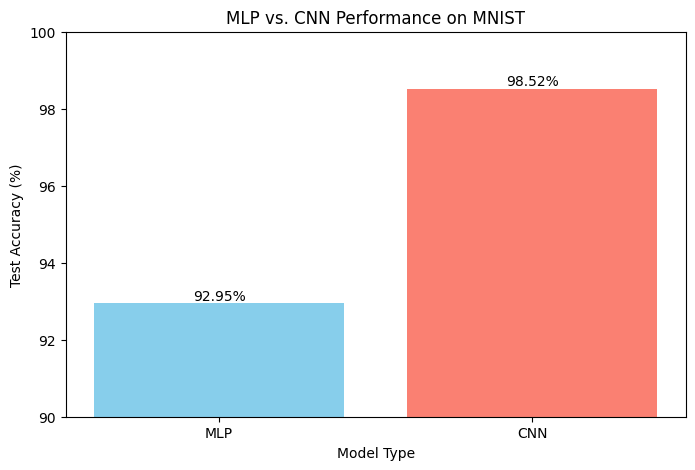

In [45]:
print(f"MLP Model Accuracy: {mlp_accuracy:.2f}%")
print(f"CNN Model Accuracy: {cnn_accuracy:.2f}%")

  สร้างกราฟแท่งเปรียบเทียบ
models = ['MLP', 'CNN']
accuracies = [mlp_accuracy, cnn_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon'])
plt.xlabel('Model Type')
plt.ylabel('Test Accuracy (%)')
plt.title('MLP vs. CNN Performance on MNIST')
plt.ylim(90, 100)   ปรับช่วงของแกน y เพื่อให้เห็นความแตกต่างของค่าความแม่นยำได้ชัดเจนยิ่งขึ้น

for bar in bars:
    yval = bar.get_height()   ดึงค่าความสูงของแต่ละแท่งกราฟ (ค่า Accuracy)
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}%', va='bottom', ha='center')   แสดงค่าตัวเลขกำกับบนแท่งกราฟแต่ละแท่ง

plt.show()

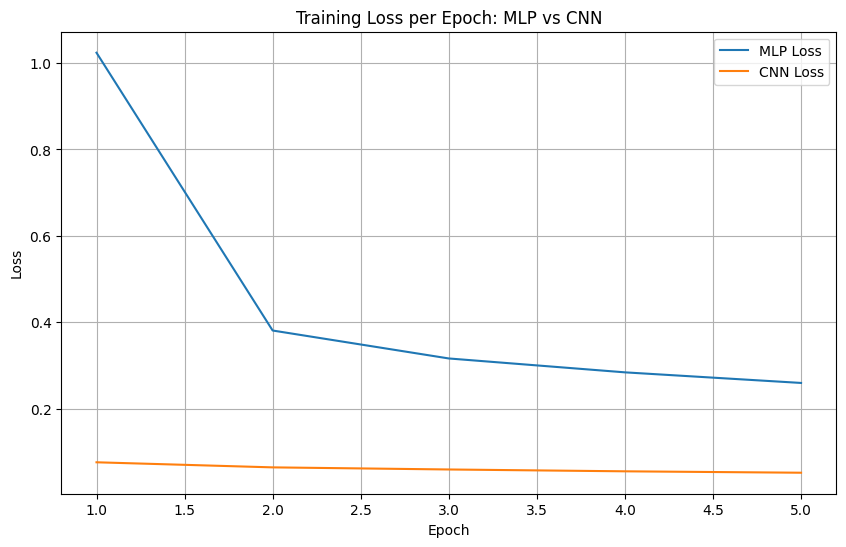

In [46]:
  พล็อตกราฟ Loss History
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), mlp_loss_history, label='MLP Loss')
plt.plot(range(1, EPOCHS + 1), cnn_loss_history, label='CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch: MLP vs CNN')
plt.legend()
plt.grid(True)
plt.show()

    สรุปผลการทดลอง

จากผลการประเมินประสิทธิภาพ พบว่าแบบจำลอง **CNN** มีค่าความแม่นยำ (Accuracy) สูงกว่าแบบจำลอง **MLP** อย่างมีนัยสำคัญ ภายใต้เงื่อนไขการฝึกสอนเดียวกัน

**ปัจจัยหลักที่ส่งผลต่อประสิทธิภาพของ CNN:**
- **การคงไว้ซึ่งโครงสร้างข้อมูล:** CNN สามารถประมวลผลข้อมูลในรูปแบบ 2 มิติได้โดยตรง จึงสามารถรักษาความสัมพันธ์เชิงพื้นที่ระหว่างพิกเซลไว้ได้
- **ความสามารถในการสกัดลักษณะเด่น:** Convolutional Layer สามารถเรียนรู้และสกัดลักษณะเด่นที่สำคัญของรูปภาพได้อย่างมีประสิทธิภาพ
- **การใช้พารามิเตอร์ร่วมกัน (Parameter Sharing):** การใช้ฟิลเตอร์ชุดเดียวกันซ้ำในส่วนต่างๆ ของรูปภาพ ช่วยลดจำนวนพารามิเตอร์ทั้งหมดของแบบจำลอง ทำให้มีประสิทธิภาพในการเรียนรู้สูงขึ้น